<a href="https://colab.research.google.com/github/kelvinXlamar/Project-101/blob/main/Quality_of_Life_Data_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#To suppress warinings for a cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

#Libraries for data processing and visualization
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

#Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance


In [ ]:
#Load the data from the csv file
data_path = '/Updated Quality of Life Data.csv'
df = pd.read_csv(data_path)

#Display first few rows of the dateset
df.head()

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,Female,Teacher,6.60,10.92,5.38,1.10,88
1,10002,Male,Office Worker,9.65,7.65,6.31,0.39,76
2,10003,Female,Manager,13.77,1.00,8.02,1.21,78
3,10004,Female,Freelancer,10.94,5.18,7.59,0.29,74
4,10005,Male,Engineer,9.81,5.11,7.38,1.70,78


Data cleaning and Preprocessing

In [ ]:
#check for data types
print(df.dtypes)

id                              int64
gender                         object
occupation_type                object
avg_work_hours_per_day        float64
avg_rest_hours_per_day        float64
avg_sleep_hours_per_day       float64
avg_exercise_hours_per_day    float64
age_at_death                    int64
dtype: object


In [ ]:
#look for missing values
print(df.isnull().sum())

#Droping duplicates
df.drop_duplicates(inplace=True)

#'id' column is not needed in this analysis so we drop it
if 'id' in df.columns:
  df.drop(columns=['id'], inplace=True)

id                            0
gender                        0
occupation_type               0
avg_work_hours_per_day        0
avg_rest_hours_per_day        0
avg_sleep_hours_per_day       0
avg_exercise_hours_per_day    0
age_at_death                  0
dtype: int64


In [17]:
df.describe()

,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,9.211857,5.964582,7.364192,1.459726,79.85060
std,2.903739,3.152097,2.214386,0.954428,12.02562
min,0.010000,0.000000,0.000000,0.000000,25.00000
25%,7.740000,3.890000,6.310000,0.650000,74.00000
50%,8.960000,5.830000,7.390000,1.440000,81.00000
75%,10.440000,7.670000,8.470000,2.250000,88.00000
max,23.970000,23.930000,19.980000,5.930000,100.00000


In [ ]:
df.shape

(10000, 7)

Exploratory Data Analysis

<function matplotlib.pyplot.show(close=None, block=None)>

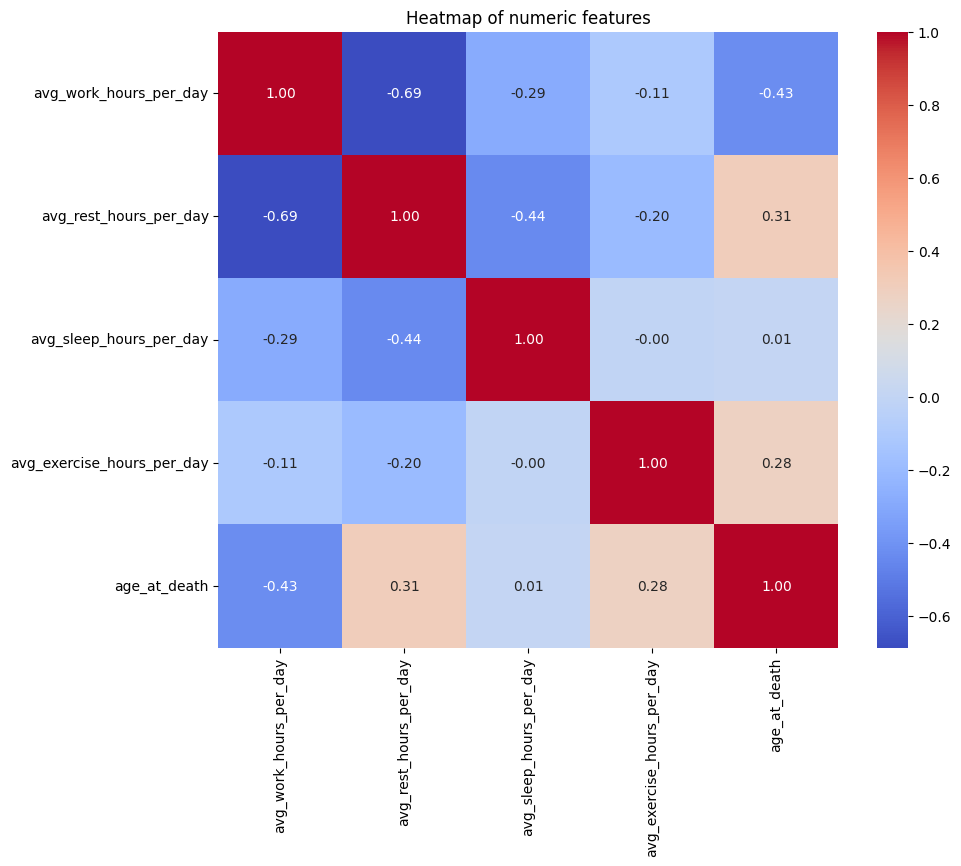

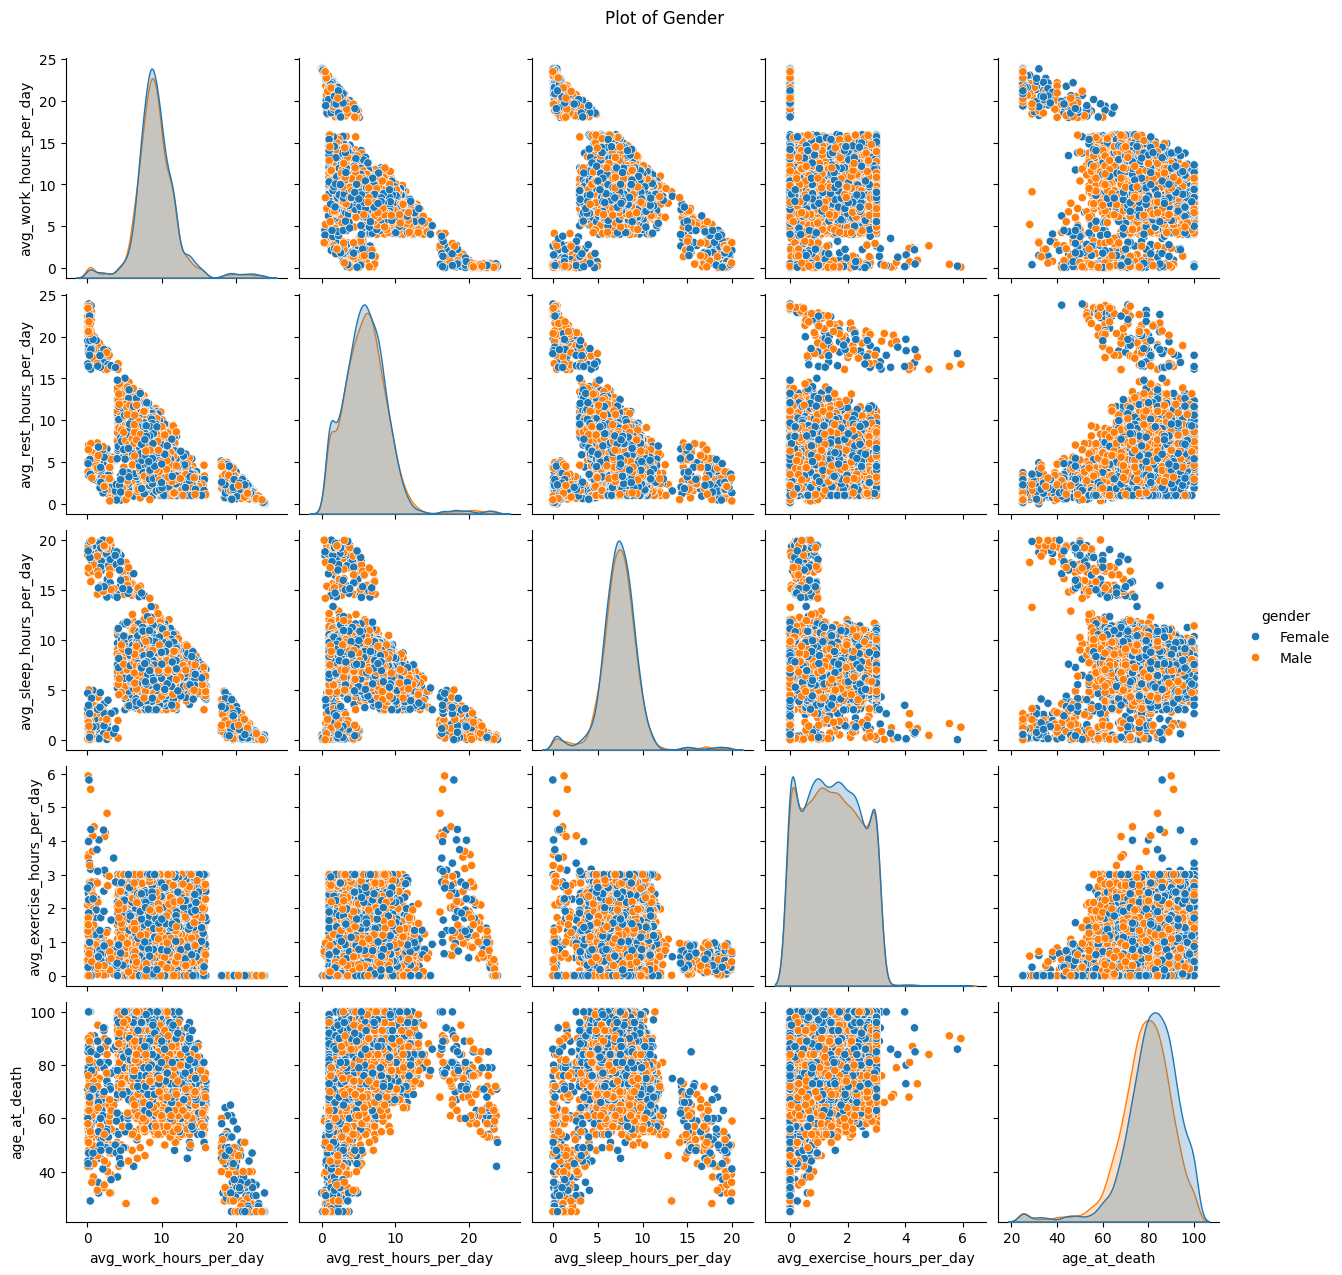

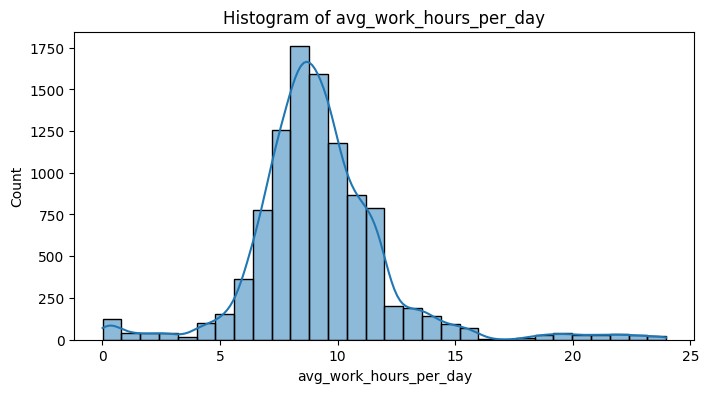

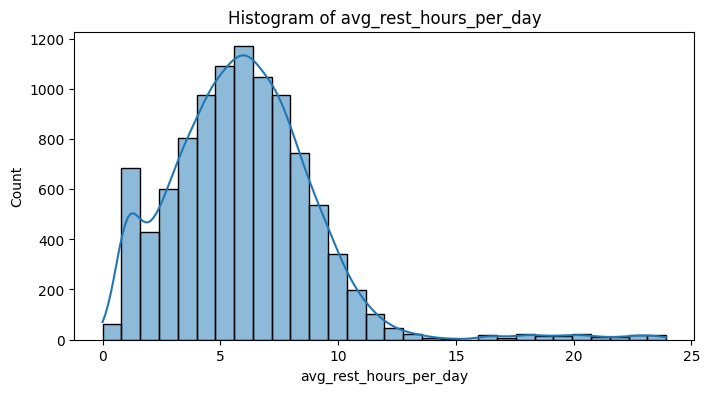

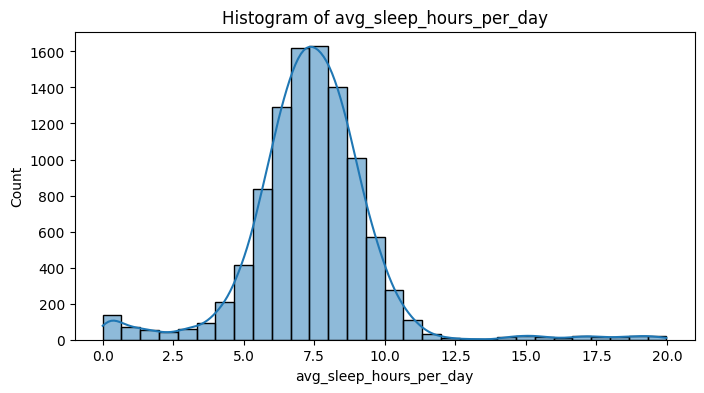

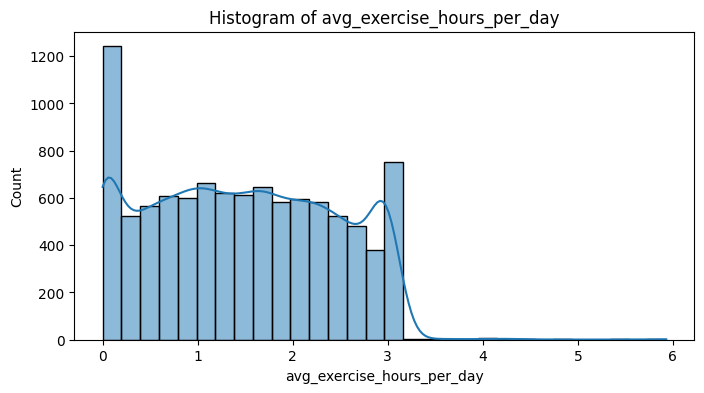

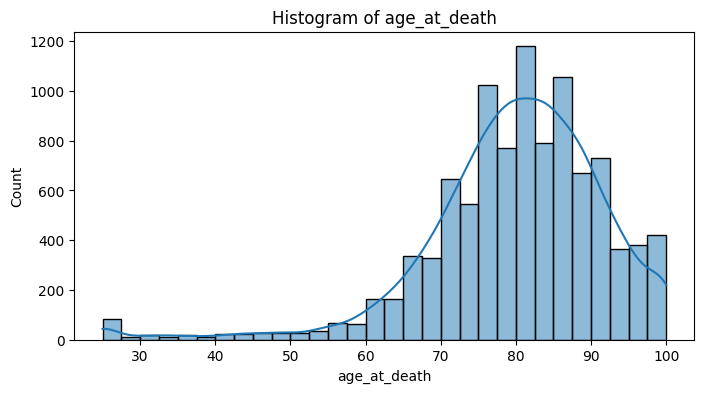

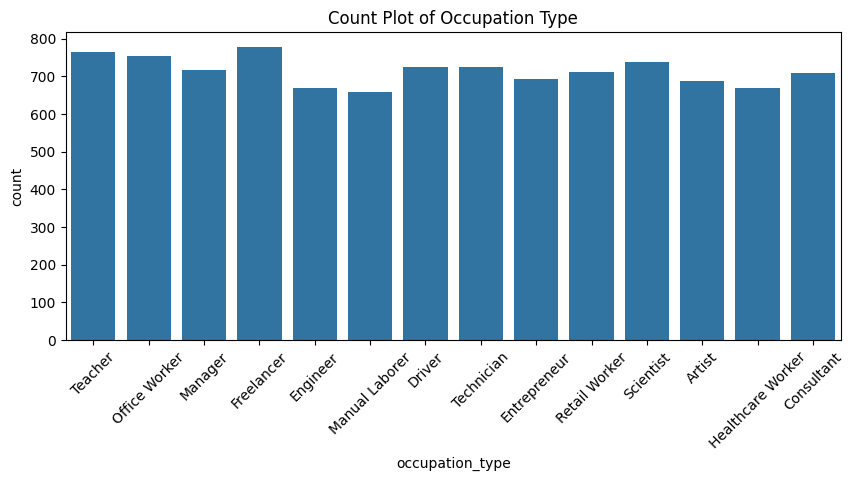

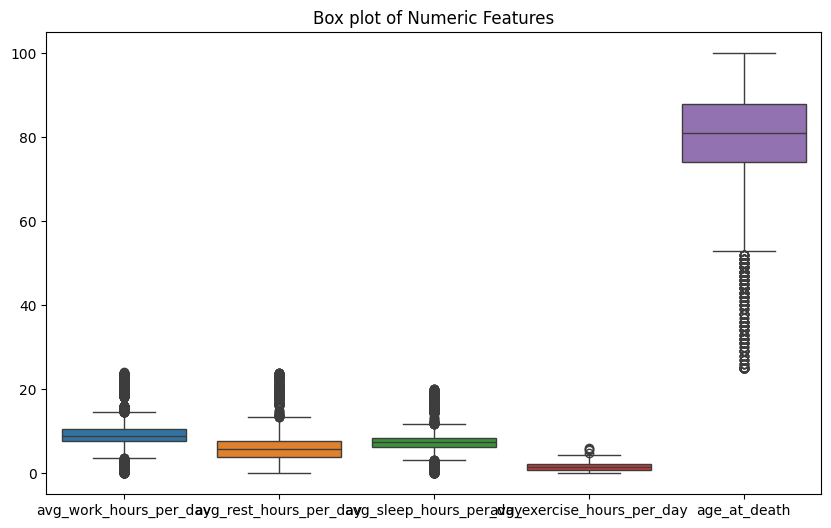

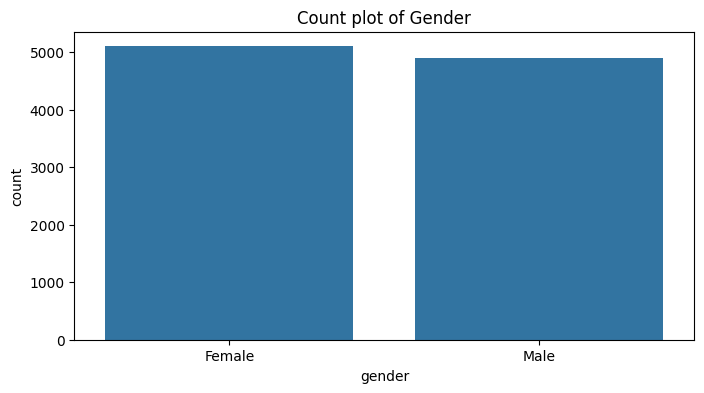

In [ ]:
#List numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

#correlation using heatmap
if numeric_df.shape[1] >= 4:
  plt.figure(figsize=(10, 8))
  corr = numeric_df.corr()
  sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
  plt.title('Heatmap of numeric features')
  plt.show

#pair plot to observe pairwise relationships
sns.pairplot(df, hue='gender')
plt.suptitle('Plot of Gender', y=1.02)
plt.show

#Histogram for each numeric feature
numeric_features = numeric_df.columns
for feature in numeric_features:
  plt.figure(figsize=(8, 4))
  sns.histplot(df[feature], kde=True, bins=30)
  plt.title(f'Histogram of {feature}')
  plt.show

plt.figure(figsize=(10, 4))
sns.countplot(x='occupation_type', data=df)
plt.title('Count Plot of Occupation Type')
plt.xticks(rotation=45)
plt.show

#Box Plot to inspect distribution and potential outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=numeric_df)
plt.title('Box plot of Numeric Features')
plt.show

#Count plot for categorical features, gender and occupation_type
plt.figure(figsize=(8, 4))
sns.countplot(x='gender', data=df)
plt.title('Count plot of Gender')
plt.show

Predictive model


R2 Score for the Age at Death Prediction: 0.532


<function matplotlib.pyplot.show(close=None, block=None)>

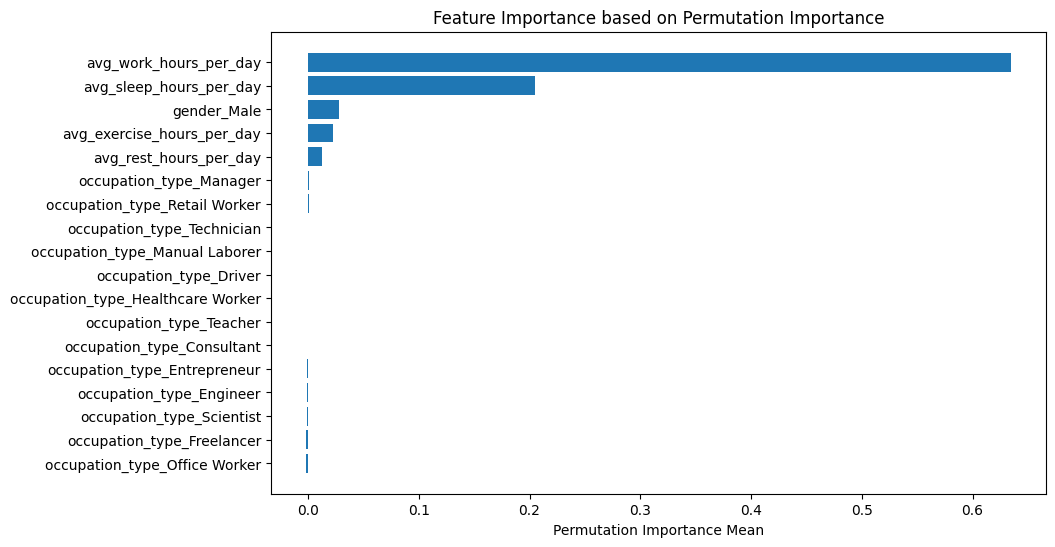

In [ ]:
# Prepare data for modeling
X = df.drop(columns=['age_at_death'])
y = df['age_at_death']

# Handle categorical variables using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the performance using R2 score
r2 = r2_score(y_test, y_pred)
print(f'R2 Score for the Age at Death Prediction: {r2:.3f}')

# Permutation Importance for feature importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel('Permutation Importance Mean')
plt.title('Feature Importance based on Permutation Importance')
plt.show